# Data visualization with ggplot

In [1]:
import pandas as pd 
import plotnine as pln

import warnings
from plotnine.exceptions import PlotnineWarning

warnings.filterwarnings("ignore", category=PlotnineWarning)

import matplotlib as mpl

%config InlineBackend.print_figure_kwargs = {'facecolor': 'white', 'bbox_inches': 'tight'}
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['savefig.transparent'] = False

The ggplot package was originally written for R users and was later released for Python under the name plotnine. Since I believe it is one of the best visualization libraries, both in terms of aesthetics and its user-friendly grammar, I chose to demonstrate its use in Python here in this notebook.

The Iris includes three iris species with 50 samples each as well as some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.

In [4]:
iris_df = pd.read_csv('data/Iris.csv')
iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## Basic Components of ggplot
* A data frame
* aesthetic mapping (aes = ): how data are mapped to position (X an Y axes), colors, size.
* geometric object: geometric object like points (geom_point), bars (geom_bars) etc..

## Scatter plot (geom_point)

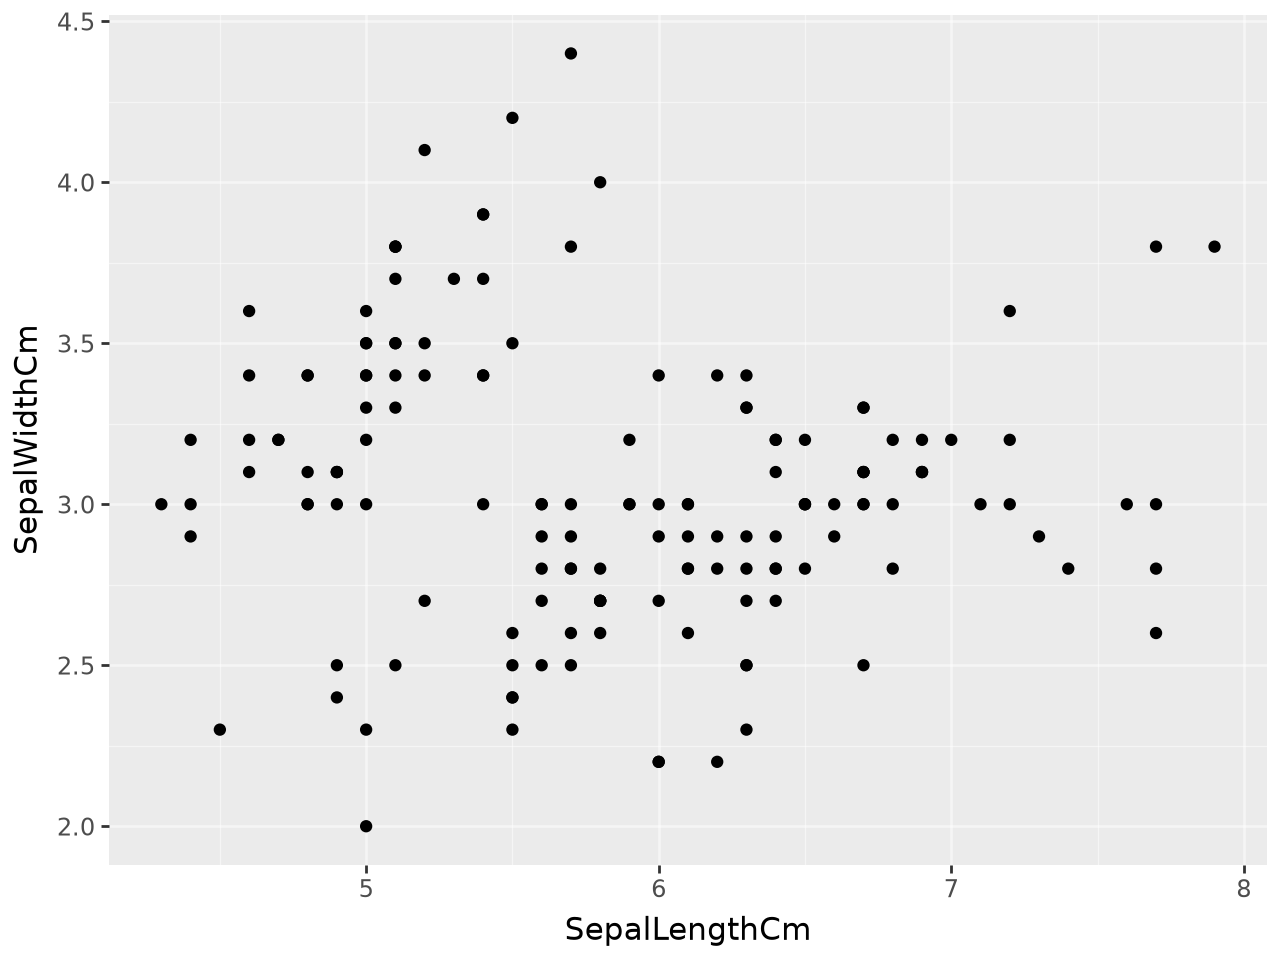

In [5]:
pln.ggplot(iris_df, pln.aes(x='SepalLengthCm' , y='SepalWidthCm')) + pln.geom_point()

Note that we used only x & y in aesthetic mapping (x='SepalLengthCm' , y='SepalWidthCm'), but we can also use color='Species' to assigen different  color to each Species group as following: 

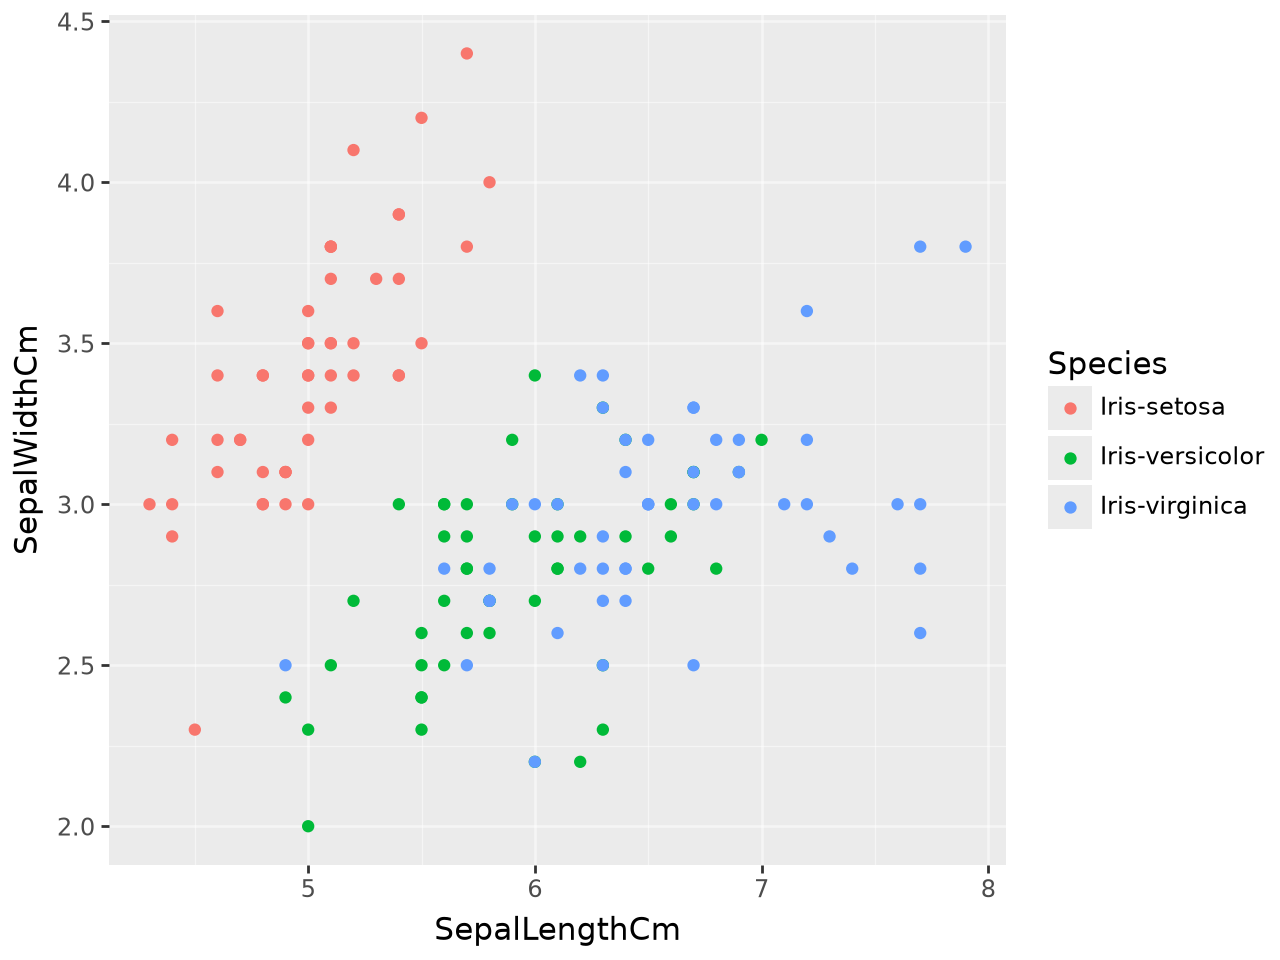

In [6]:
pln.ggplot(iris_df, pln.aes(x='SepalLengthCm' , y='SepalWidthCm', color='Species')) + pln.geom_point()

Or alternatively use shape to assigen different shape to each Species group as following:

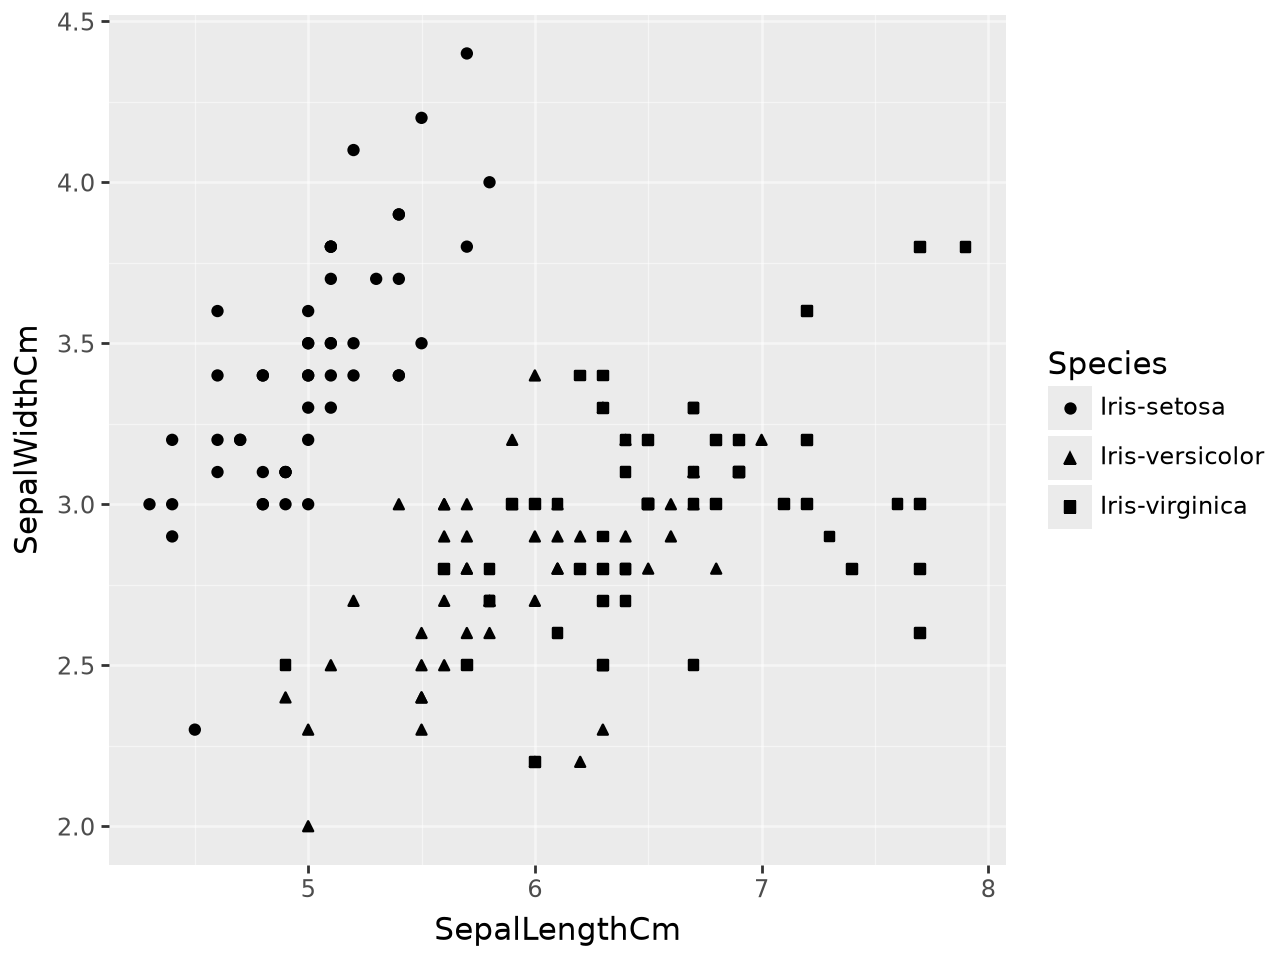

In [7]:
pln.ggplot(iris_df, pln.aes(x='SepalLengthCm' , y='SepalWidthCm', shape='Species')) + pln.geom_point()

There is also the option to split the plot by group with  facet_wrap option: 

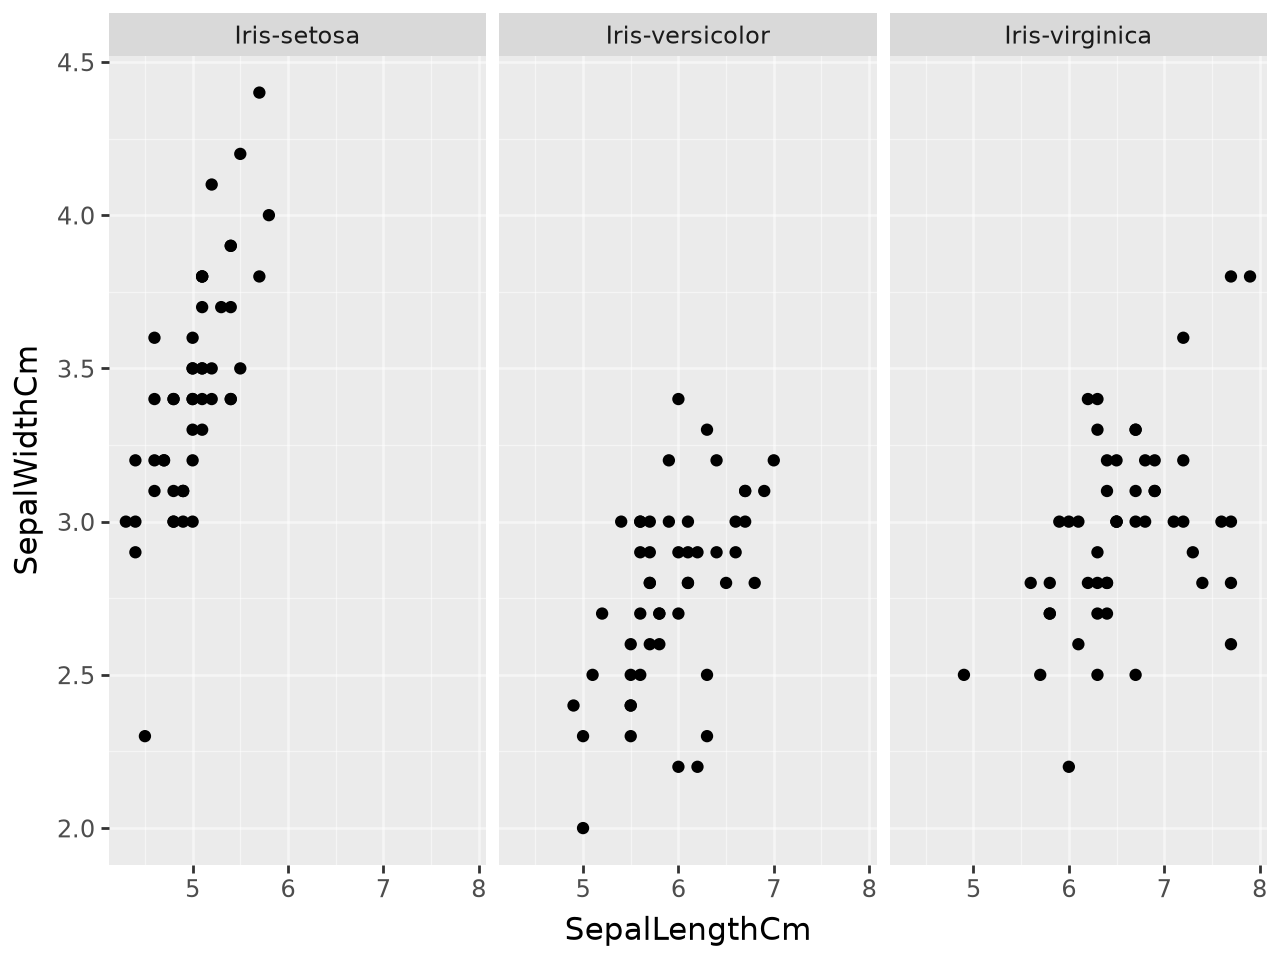

In [8]:
pln.ggplot(iris_df, pln.aes(x='SepalLengthCm' , y='SepalWidthCm')) + pln.geom_point() + pln.facet_wrap('Species')


# Histogram (geom_histogram) 

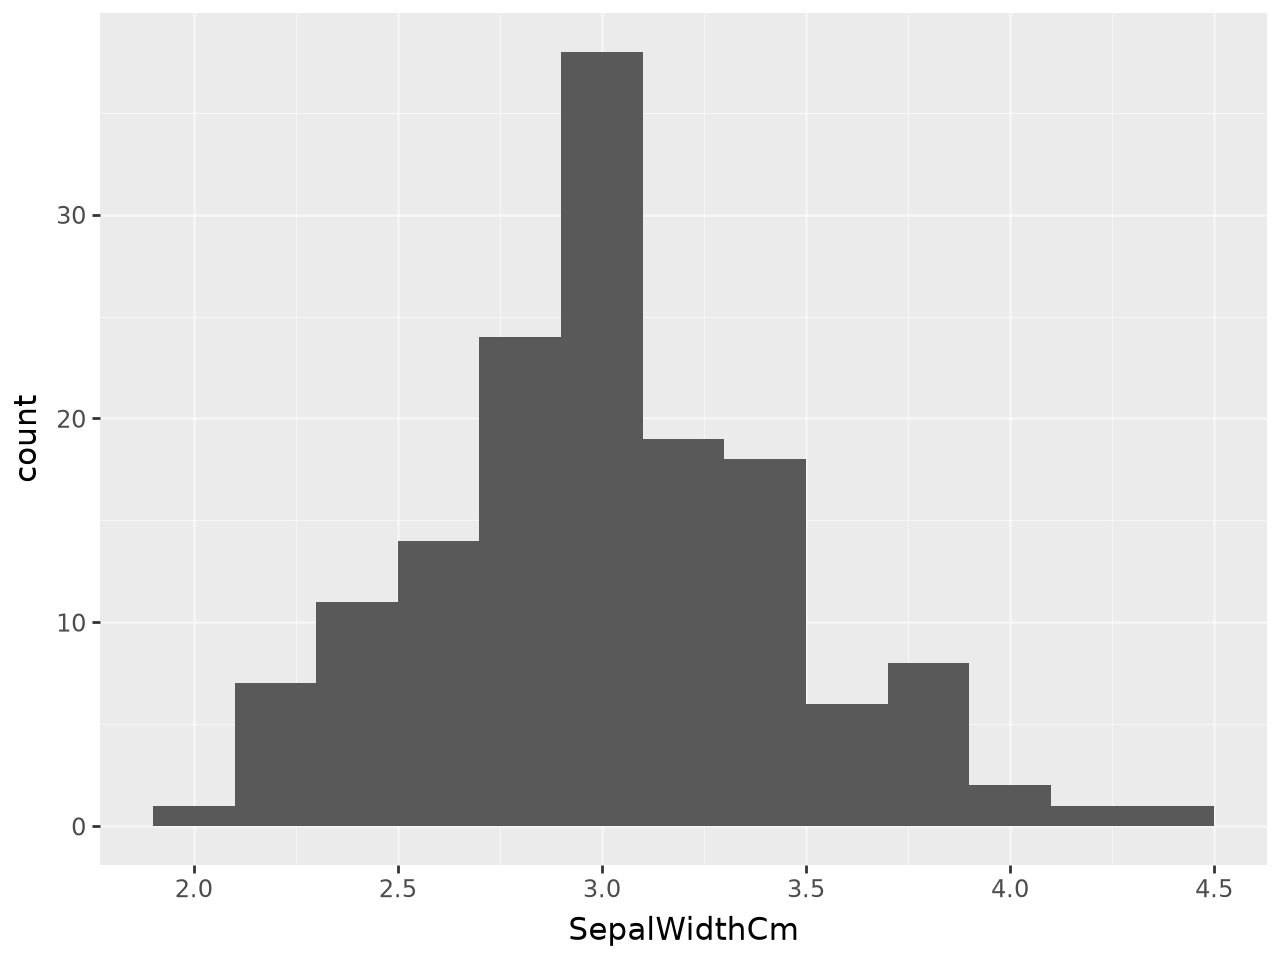

In [9]:
pln.ggplot(iris_df, pln.aes(x='SepalWidthCm')) + pln.geom_histogram()

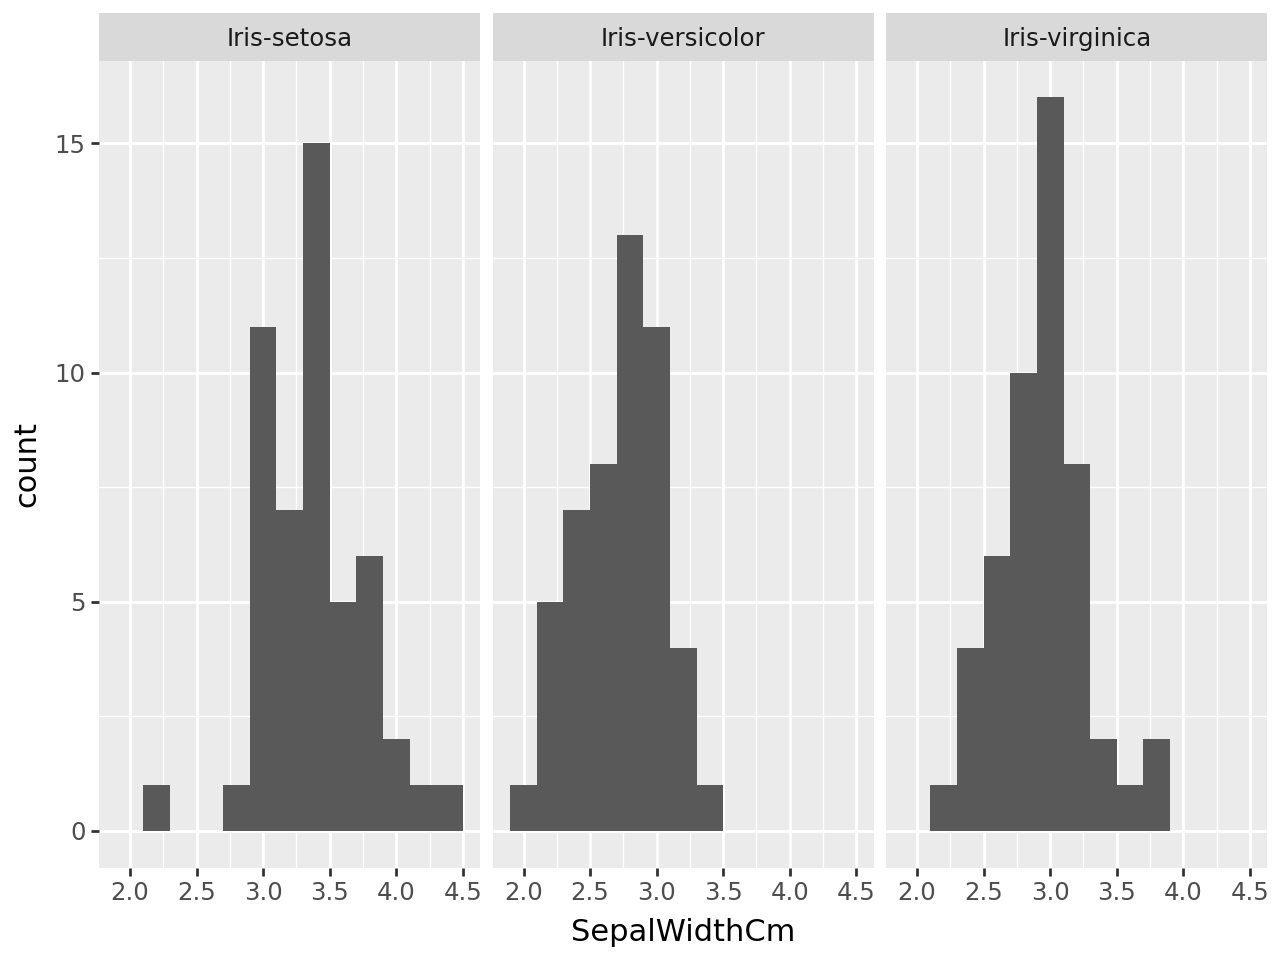

In [14]:

pln.ggplot(iris_df, pln.aes(x='SepalWidthCm')) + pln.geom_histogram() + pln.facet_wrap('Species')


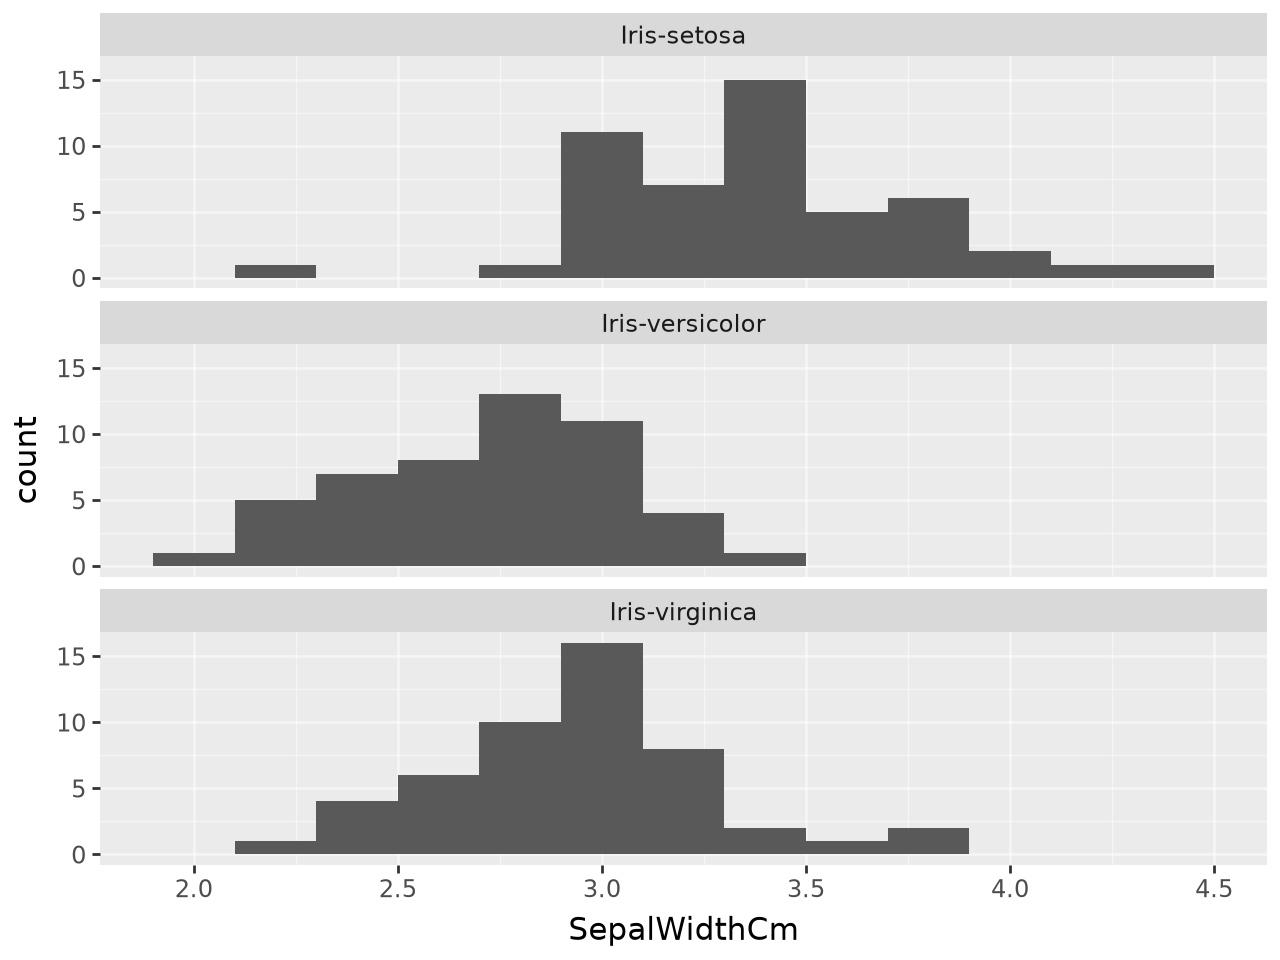

In [10]:
pln.ggplot(iris_df, pln.aes(x='SepalWidthCm')) + pln.geom_histogram() + pln.facet_wrap('Species', nrow=3)

Another advantage in ggplot is that we can add each plot layer from a diffrent dataframe:

In [11]:

setosa_df = iris_df.loc[iris_df['Species']=='Iris-setosa']

versicolor_df = iris_df.loc[iris_df['Species']=='Iris-versicolor']


And use fill in in aesthetic mapping to choose color

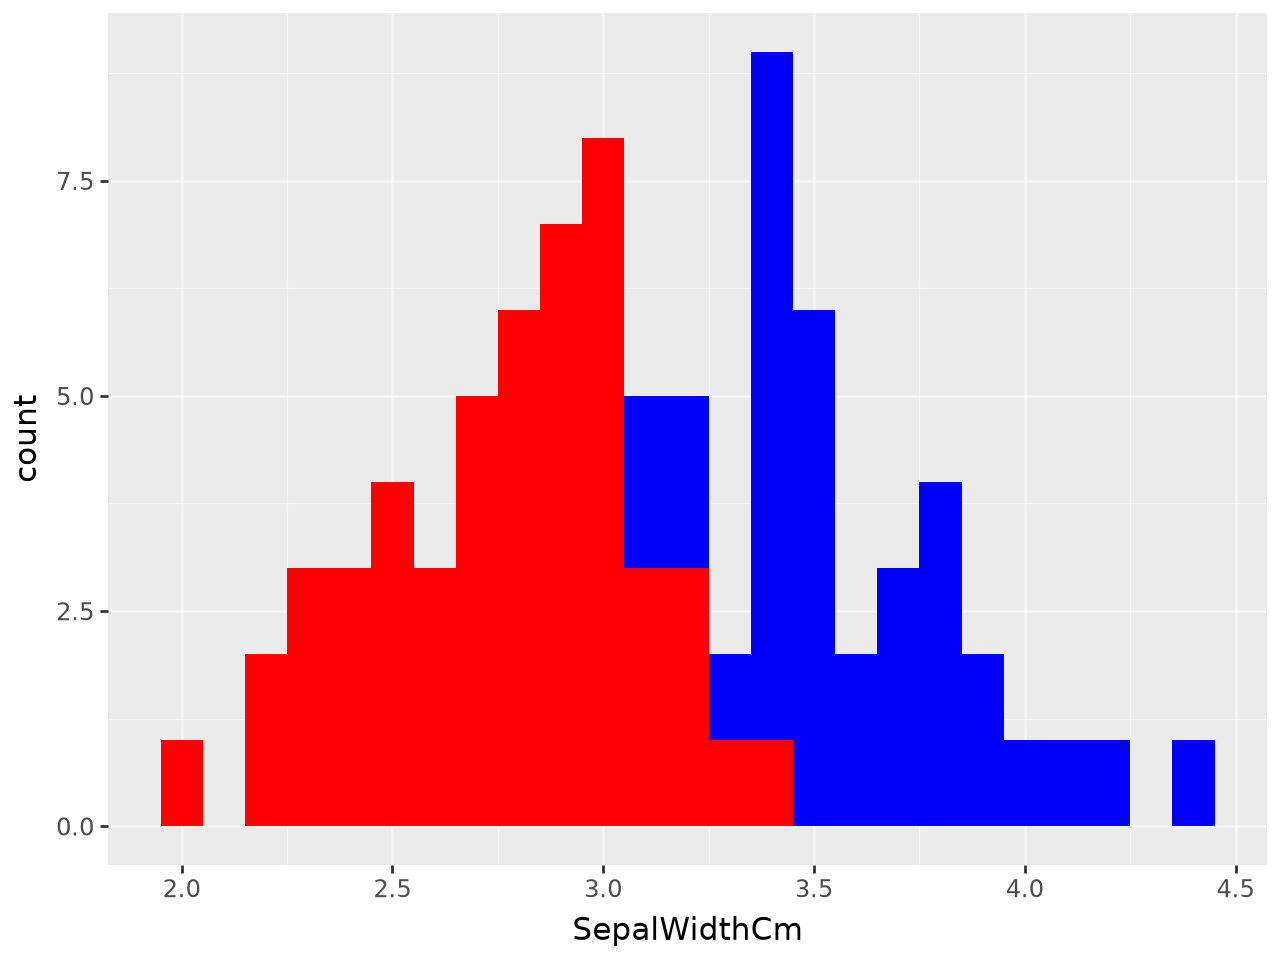

In [12]:
pln.ggplot() + \
    pln.geom_histogram(setosa_df, pln.aes(x='SepalWidthCm'), binwidth=0.1, fill = 'blue') + \
            pln.geom_histogram(versicolor_df, pln.aes(x='SepalWidthCm'), binwidth=0.1, fill = 'red')

In layer case it is recommended to add transparency with alpha parameter  

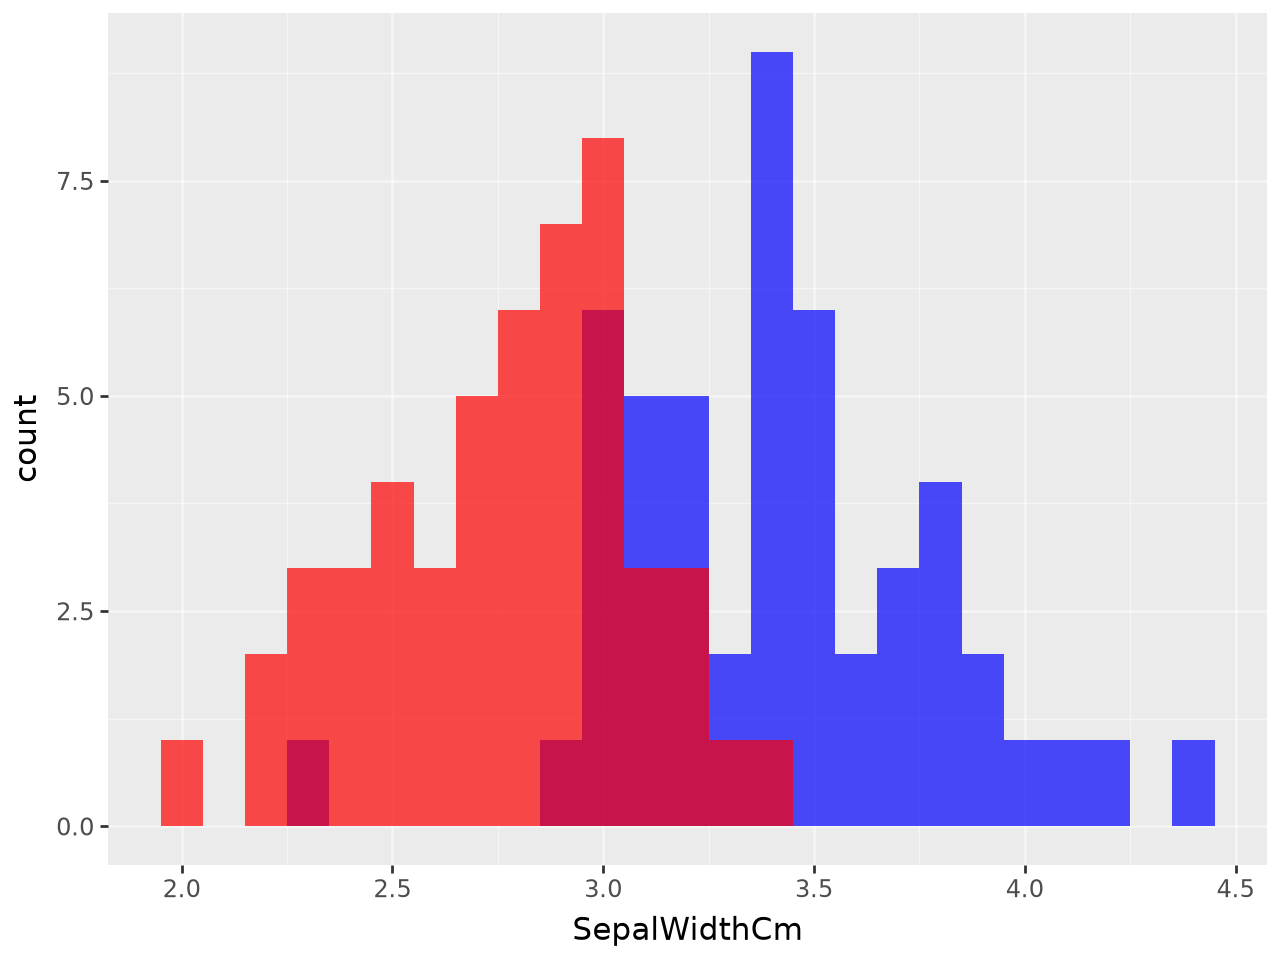

In [13]:
pln.ggplot() + \
    pln.geom_histogram(setosa_df, pln.aes(x='SepalWidthCm'), binwidth=0.1, fill = 'blue', alpha=0.7) + \
            pln.geom_histogram(versicolor_df, pln.aes(x='SepalWidthCm'), binwidth=0.1, fill = 'red', alpha=0.7)

# Boxplot (geom_boxplot)

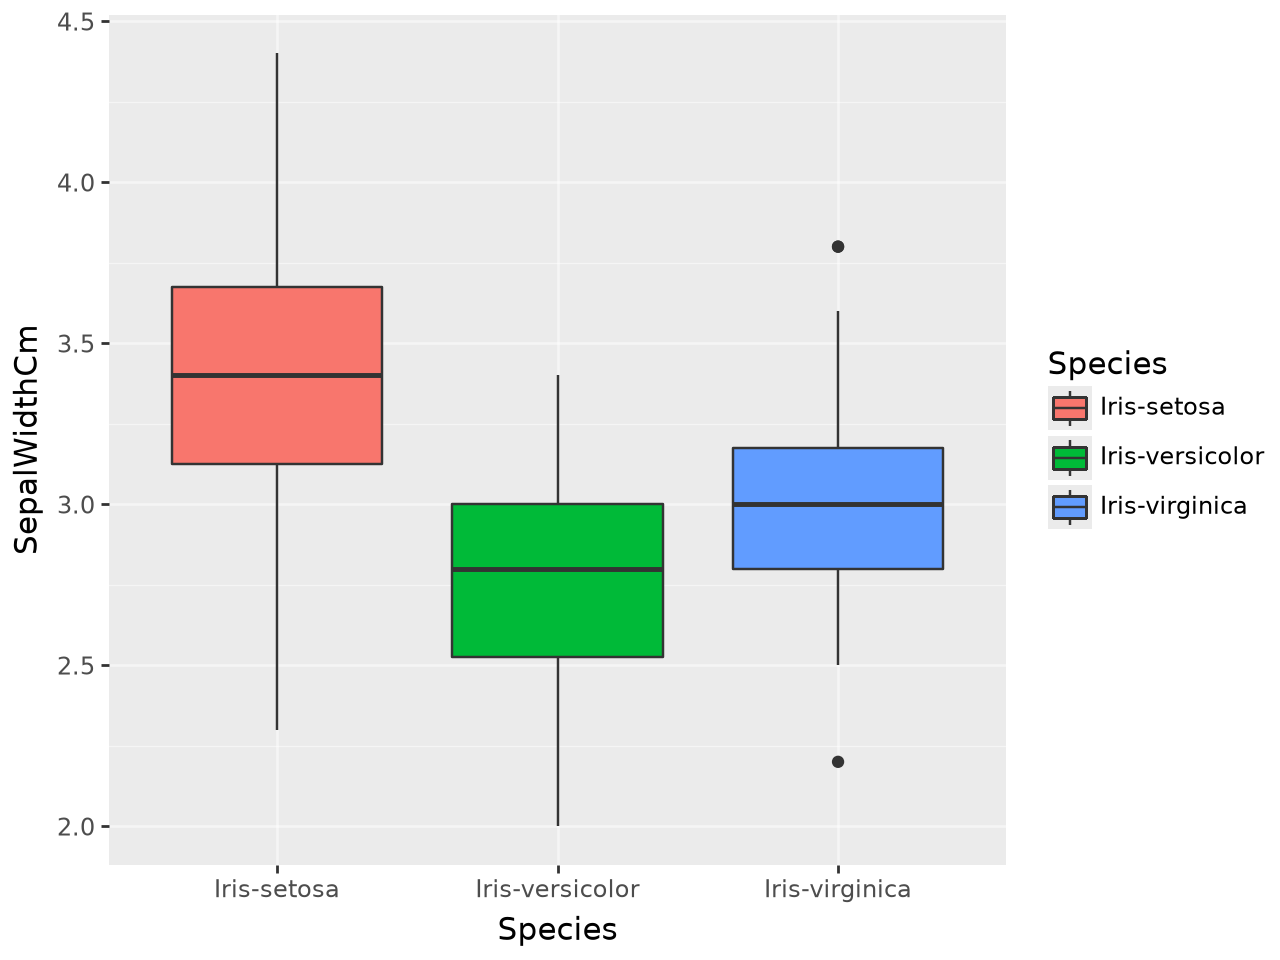

In [14]:

pln.ggplot(iris_df, pln.aes(x='Species' ,y='SepalWidthCm', fill='Species')) + pln.geom_boxplot()


I like to add the scatter points on top of the bars to see their spred with + geom_jitter()


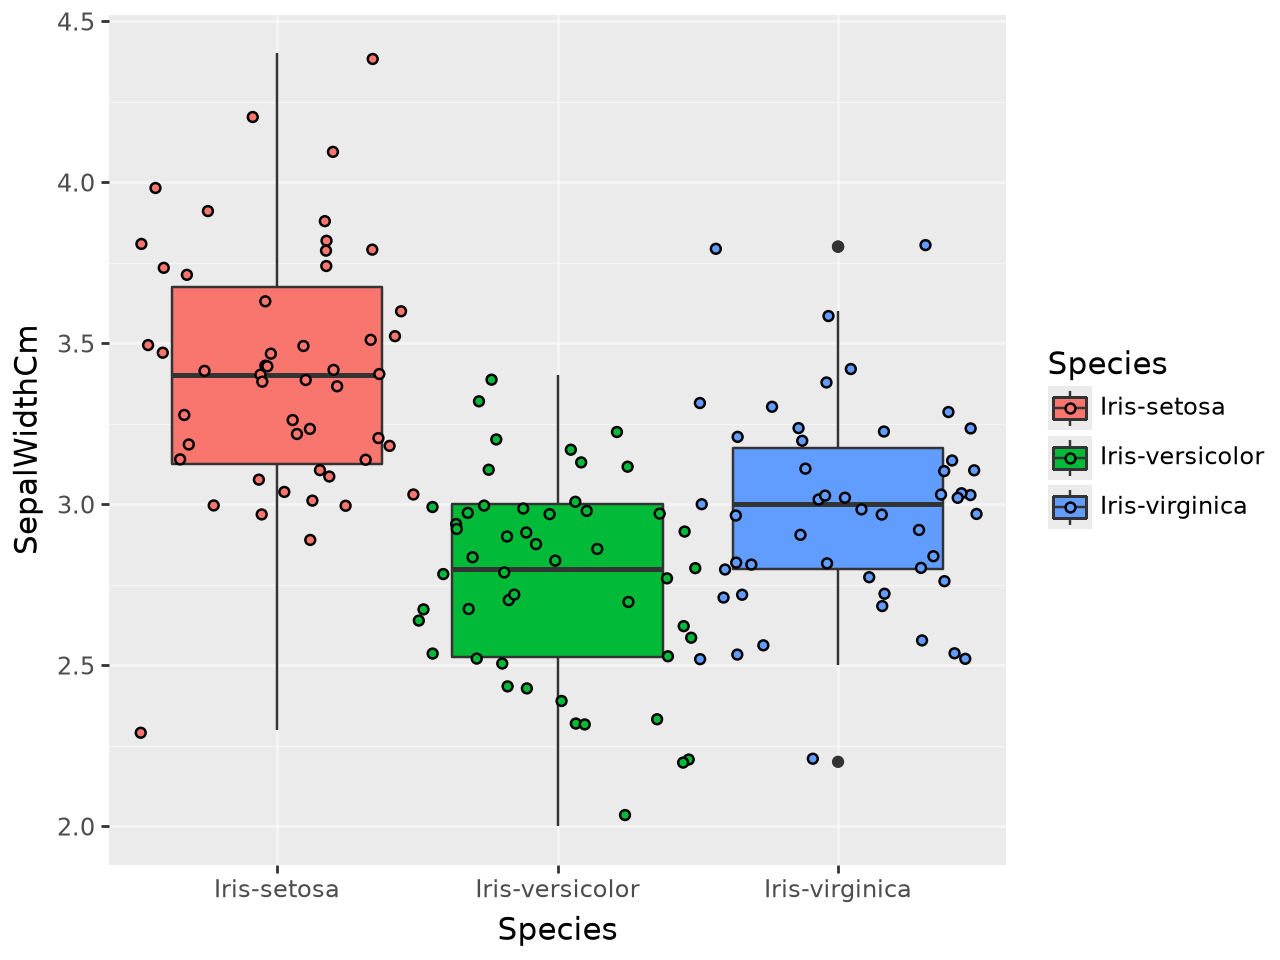

In [15]:

pln.ggplot(iris_df, pln.aes(x='Species' ,y='SepalWidthCm', fill='Species')) + pln.geom_boxplot() + pln.geom_jitter(width = 0.5)



Note the width parameter I used to introduce some randomness along the x-axis (which has no real meaning here, only the y-axis is meaningful). Without this jitter, the points would overlap, making them harder to distinguish.

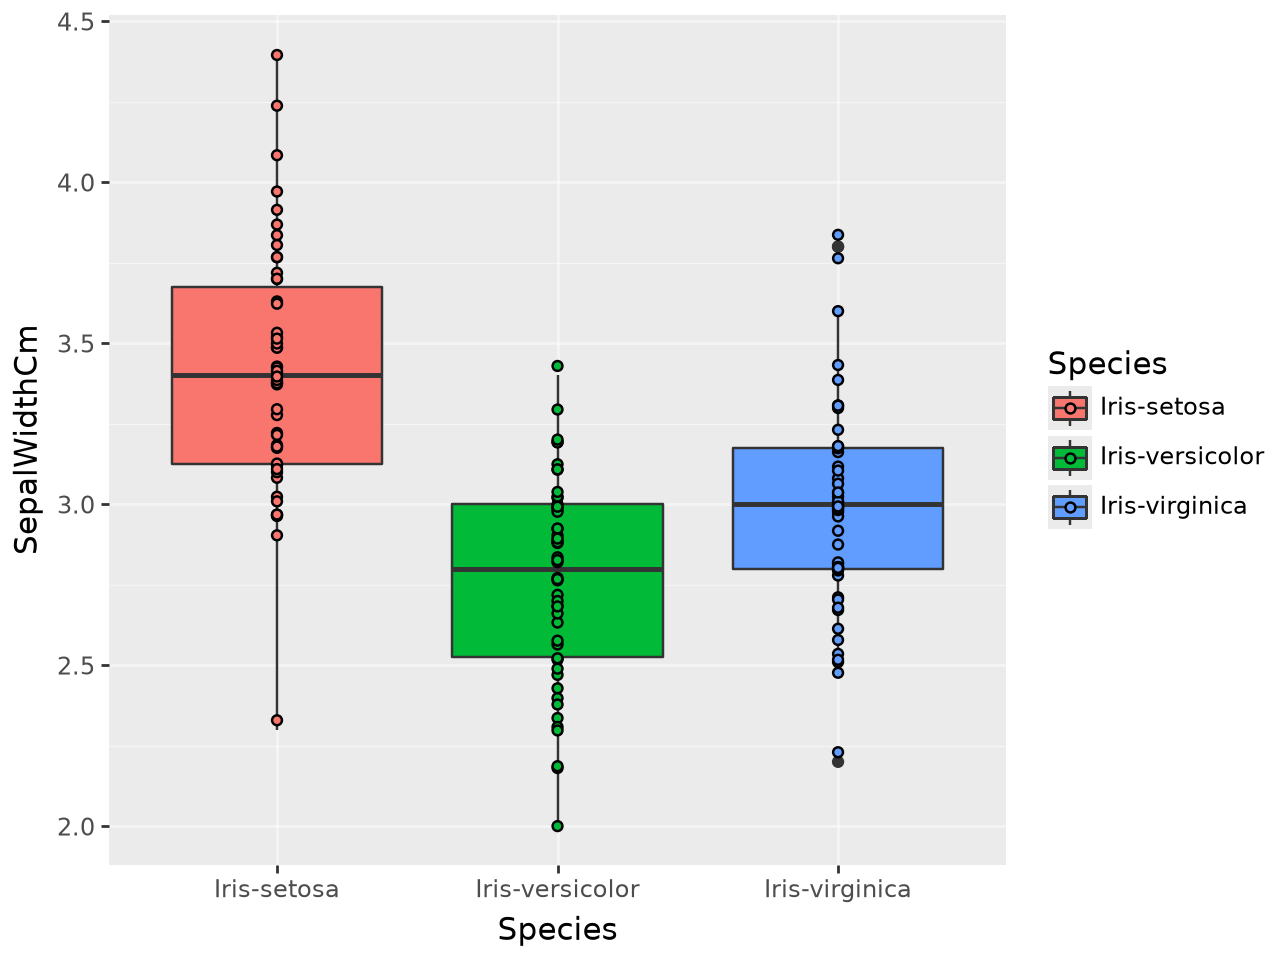

In [16]:
pln.ggplot(iris_df, pln.aes(x='Species' ,y='SepalWidthCm', fill='Species')) + pln.geom_boxplot() + pln.geom_jitter(width = 0)

finally, lets play with labels of axis, header of plot and colors of bars: 

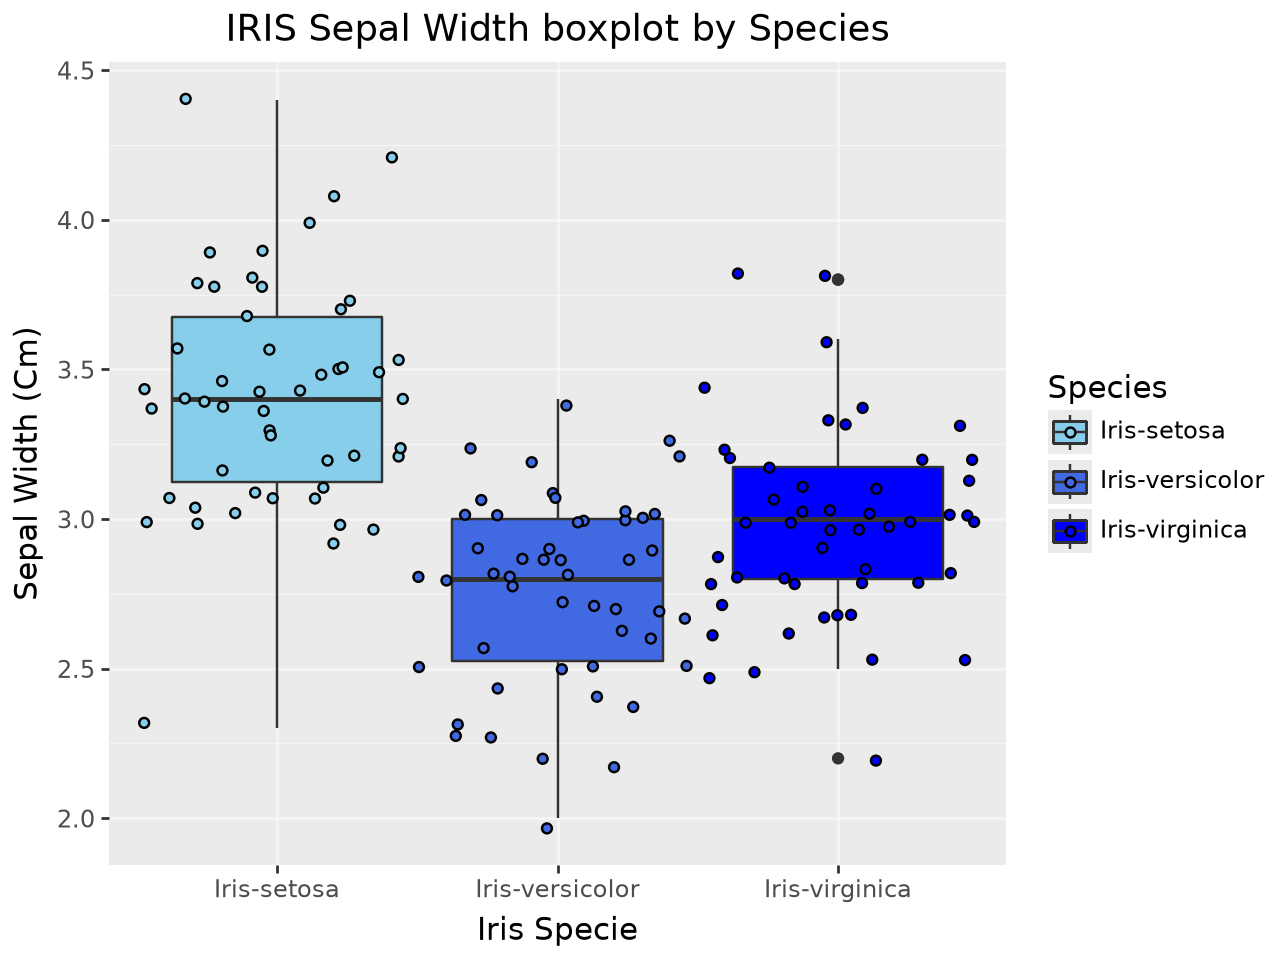

In [17]:
pln.ggplot(iris_df, pln.aes(x='Species' ,y='SepalWidthCm', fill='Species')) + \
    pln.geom_boxplot() + \
        pln.geom_jitter(width = 0.5) + \
            pln.xlab('Iris Specie') + \
                pln.ylab('Sepal Width (Cm)') + \
                    pln.ggtitle('IRIS Sepal Width boxplot by Species') + \
                        pln.scale_fill_manual(values = ["skyblue", "royalblue", "blue"])
          

And maybe also range of Y axis(we can do it in 2 different ways): 

1. use ylim:

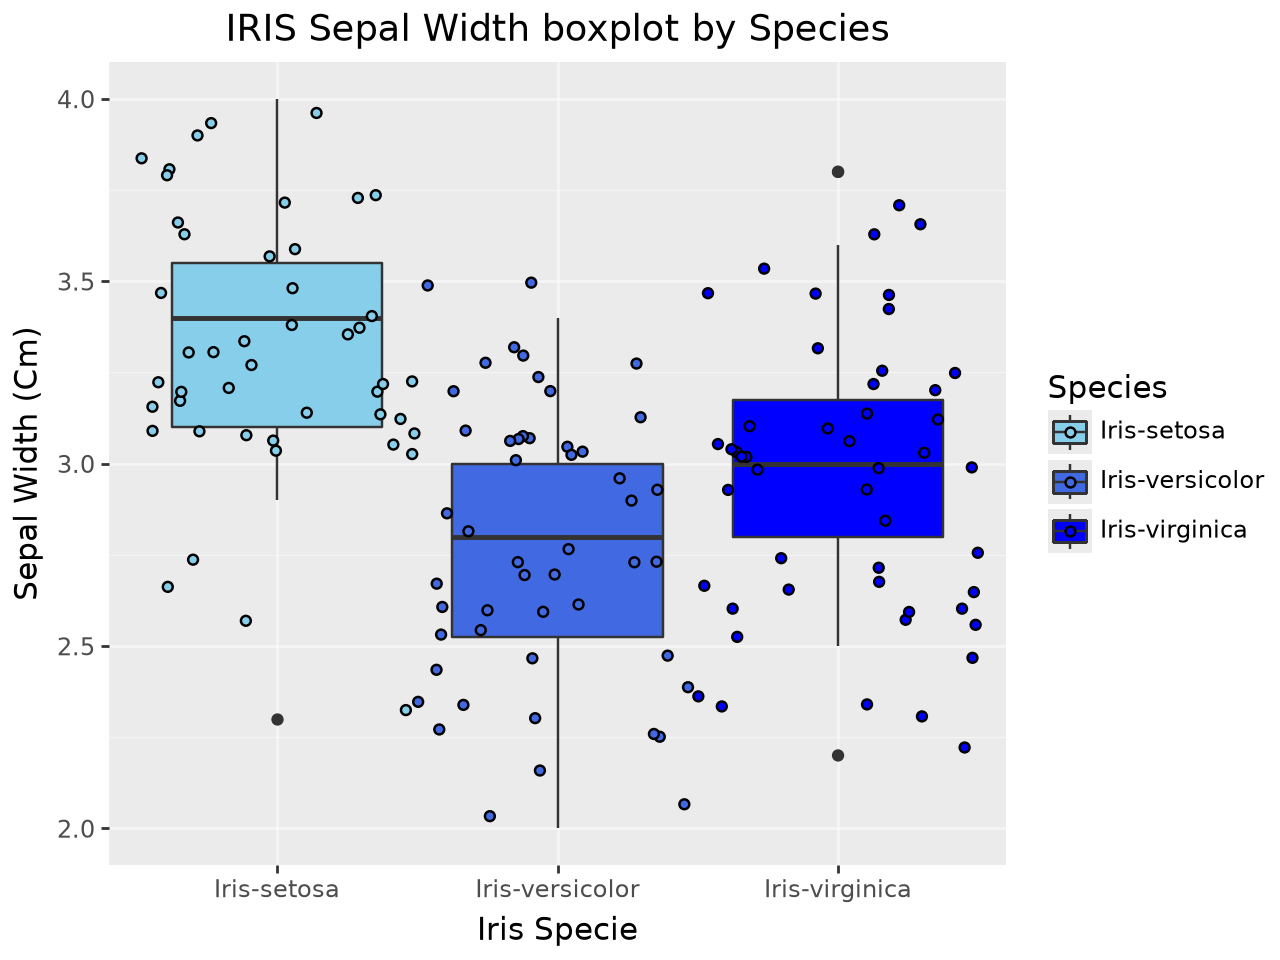

In [18]:
pln.ggplot(iris_df, pln.aes(x='Species' ,y='SepalWidthCm', fill='Species')) + \
    pln.geom_boxplot() + \
        pln.geom_jitter(width = 0.5) + \
            pln.xlab('Iris Specie') + \
                pln.ylab('Sepal Width (Cm)') + \
                    pln.ggtitle('IRIS Sepal Width boxplot by Species') + \
                        pln.scale_fill_manual(values = ["skyblue", "royalblue", "blue"]) + \
                            pln.ylim(2,4)

2. use scale_y_continuous(limits = )

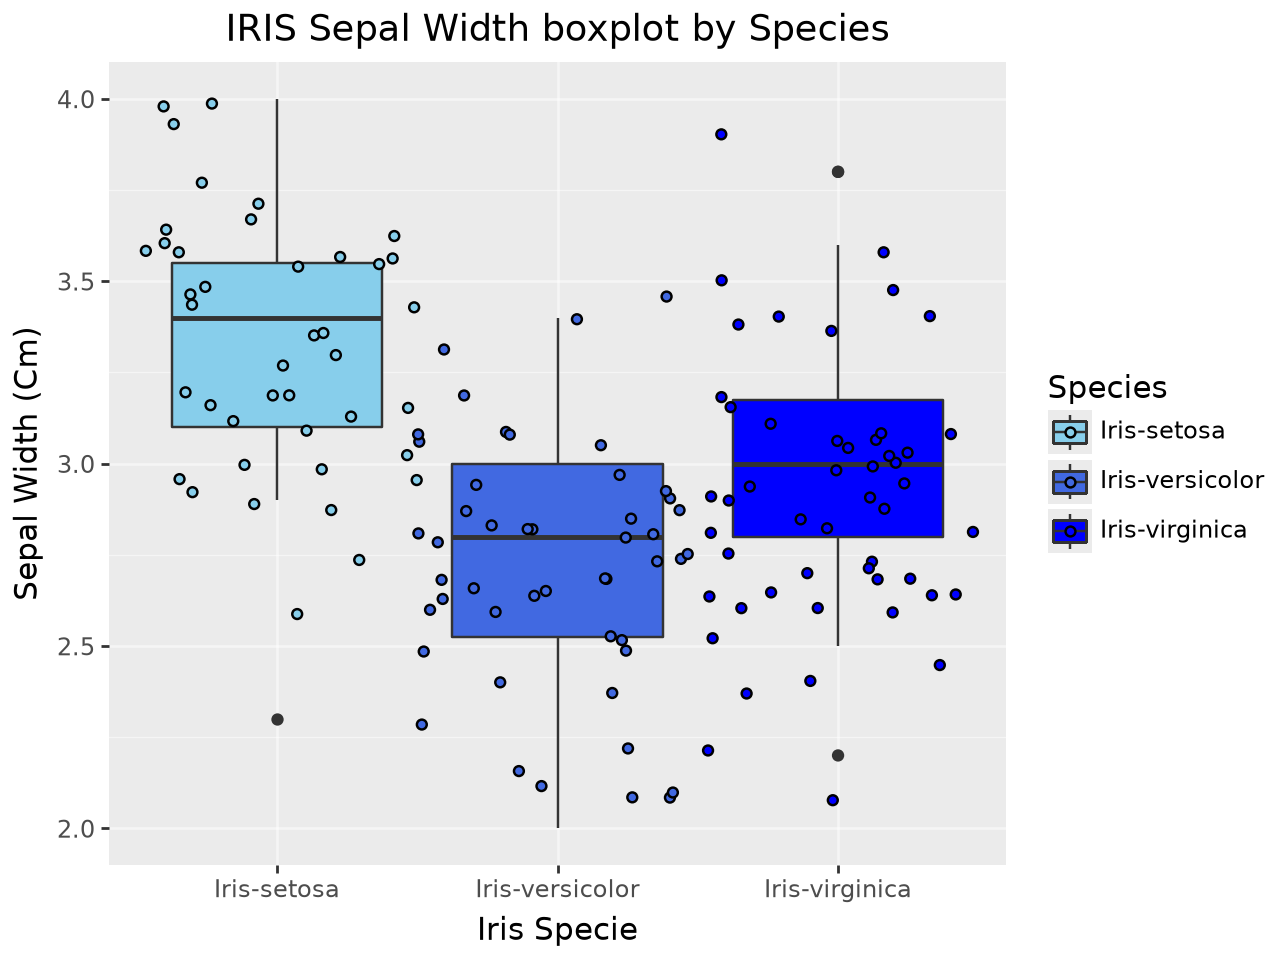

In [19]:
pln.ggplot(iris_df, pln.aes(x='Species' ,y='SepalWidthCm', fill='Species')) + \
    pln.geom_boxplot() + \
        pln.geom_jitter(width = 0.5) + \
            pln.xlab('Iris Specie') + \
                pln.ylab('Sepal Width (Cm)') + \
                    pln.ggtitle('IRIS Sepal Width boxplot by Species') + \
                        pln.scale_fill_manual(values = ["skyblue", "royalblue", "blue"]) + \
                            pln.scale_y_continuous(limits = [2,4])